✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\43_rk4_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\43_rk4_3d.png

--- Grafik Önizleme Hazırlanıyor ---


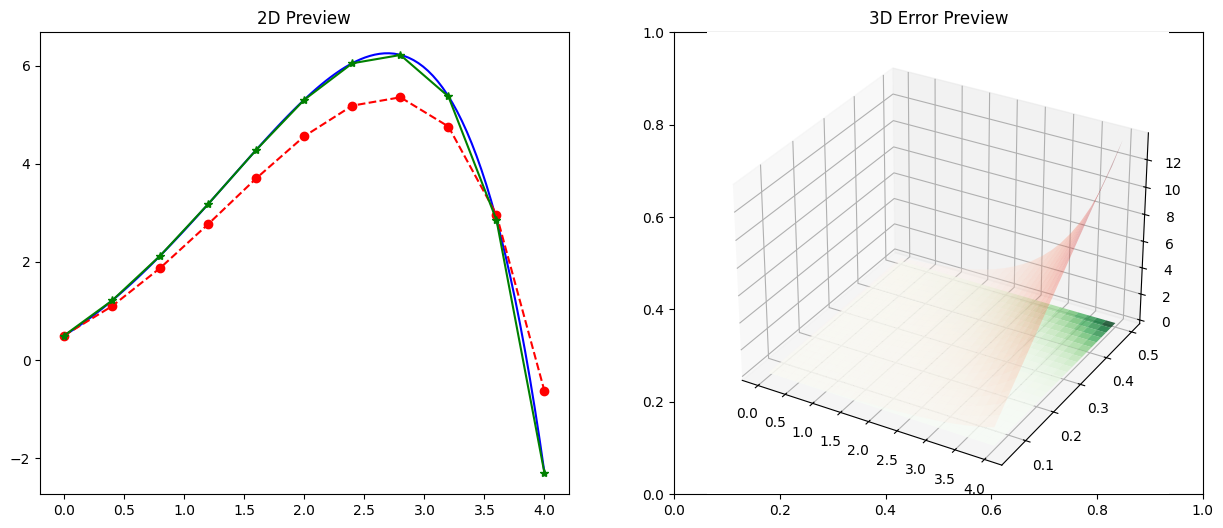

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_rk4_master_precision_fixed():
    # --- YOL AYARI ---
    asset_path = r'C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Diferansiyel Denklem: dy/dx = y - x**2 + 1 | y(0) = 0.5
    # Çözüm: y = (x+1)**2 - 0.5*e^x
    def f(x, y): return y - x**2 + 1
    def exact_sol(x): return (x + 1)**2 - 0.5 * np.exp(x)

    x0, y0, x_end, h = 0, 0.5, 4, 0.4 # Adımı biraz küçültelim ki RK4 başarısı parlasın
    steps = int((x_end - x0) / h)
    
    # Kaplar
    x_vals = np.linspace(x0, x_end, steps + 1)
    y_euler = np.zeros(steps + 1); y_rk4 = np.zeros(steps + 1)
    y_euler[0] = y_rk4[0] = y0

    # Hassas Çözücü Döngüsü
    for i in range(steps):
        curr_x, curr_y_e, curr_y_rk = x_vals[i], y_euler[i], y_rk4[i]
        
        # --- Euler Adımı ---
        y_euler[i+1] = curr_y_e + h * f(curr_x, curr_y_e)
        
        # --- RK4 Adımı ---
        k1 = f(curr_x, curr_y_rk)
        k2 = f(curr_x + h/2, curr_y_rk + h*k1/2)
        k3 = f(curr_x + h/2, curr_y_rk + h*k2/2)
        k4 = f(curr_x + h, curr_y_rk + h*k3)
        y_rk4[i+1] = curr_y_rk + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    # --- 📸 ASSET 1: 2D COMPARISON (43_rk4_2d.png) ---
    fig1 = plt.figure(figsize=(10, 7))
    x_fine = np.linspace(x0, x_end, 100)
    plt.plot(x_fine, exact_sol(x_fine), 'b-', lw=3, label='Exact Solution', alpha=0.6)
    plt.plot(x_vals, y_euler, 'ro--', label='Euler Approximation')
    plt.plot(x_vals, y_rk4, 'g*-', lw=2, label='RK4 Approximation')
    
    plt.title("Numerical Precision: Euler vs. Runge-Kutta (RK4)", fontsize=14)
    plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(os.path.join(asset_path, '43_rk4_2d.png'), dpi=300)
    plt.close(fig1)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\43_rk4_2d.png")

    # --- 📸 ASSET 2: 3D ERROR FLOOR (43_rk4_3d.png) ---
    # Bu kısmı tamamen bağımsız bir figürde ve açık bir subplot ile tanımlıyoruz
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    # H değerleri ve X değerleri üzerinden hata analizi
    h_vals = np.linspace(0.05, 0.5, 25)
    x_vals_fine = np.linspace(0, 4, 25)
    H, X = np.meshgrid(h_vals, x_vals_fine)
    
    # Teorik birikimli hata yüzeyi (Euler vs RK4)
    # RK4 hatası h^4 ile, Euler hatası h^1 ile orantılıdır
    E_euler = np.abs(np.exp(X) * H * 0.5) # Yaklaşık Euler hatası
    E_rk4 = np.abs(np.exp(X) * (H**4) * 0.01) # Yaklaşık RK4 hatası

    # Euler hatasını (Red) ve RK4 hatasını (Green) yanyana değil, üst üste çiziyoruz
    surf1 = ax3d.plot_surface(X, H, E_euler, cmap='Reds', alpha=0.3, edgecolor='none', label='Euler Error')
    surf2 = ax3d.plot_surface(X, H, E_rk4, cmap='Greens', alpha=0.8, edgecolor='none', label='RK4 Error')
    
    ax3d.set_title("3D Error Magnitude: Euler (Red) vs. RK4 (Green)", fontsize=14)
    ax3d.set_xlabel('x'); ax3d.set_ylabel('Step Size (h)'); ax3d.set_zlabel('Absolute Error')
    
    # Eksen etiketlerinin düzgün görünmesini sağla
    ax3d.xaxis.set_rotate_label(False); ax3d.yaxis.set_rotate_label(False); ax3d.zaxis.set_rotate_label(False)
    
    plt.savefig(os.path.join(asset_path, '43_rk4_3d.png'), dpi=300)
    plt.close(fig2)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\43_rk4_3d.png")

    # --- 🖥️ DASHBOARD (Visual Confirmation) ---
    # Sadece ekranda her şeyin yolunda olduğunu görmek için
    print("\n--- Grafik Önizleme Hazırlanıyor ---")
    fig_check, (ax_check1, ax_check2) = plt.subplots(1, 2, figsize=(15, 6))
    ax_check1.plot(x_fine, exact_sol(x_fine), 'b')
    ax_check1.plot(x_vals, y_euler, 'ro--')
    ax_check1.plot(x_vals, y_rk4, 'g*-')
    ax_check1.set_title("2D Preview")
    
    ax_check2 = fig_check.add_subplot(122, projection='3d')
    ax_check2.plot_surface(X, H, E_euler, cmap='Reds', alpha=0.3)
    ax_check2.plot_surface(X, H, E_rk4, cmap='Greens', alpha=0.8)
    ax_check2.set_title("3D Error Preview")
    plt.show()

if __name__ == "__main__":
    run_rk4_master_precision_fixed()